In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
events_timeline = pd.read_csv('../data/geopolitical_events_timeline.csv')
oil_geopolitics = pd.read_csv('../data/oil_geopolitics_dataset_2010_2026.csv')

# Analyzing Data Types
First, I take an initial look at the dataset and look at the data types of each column.

In [40]:
events_timeline.head()


,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


In [42]:
events_timeline.dtypes

date                   str
event_type             str
event_description      str
event_severity       int64
dtype: object

Everything looks okay except for the `date` column. I convert it to a `DateTime` object so we can query values such as the **day**, **month**, and **year** of each date for more advanced queries.

In [44]:
corrected_dates = events_timeline['date']

# %Y-%m-%d is the format followed in the data (e.g. 2011-03-19) is March 19, 2011
corrected_dates = pd.to_datetime(corrected_dates, format='%Y-%m-%d')

# Change the date column to the corrected dates column
events_timeline['date'] = corrected_dates

Quick sanity check

In [45]:
events_timeline.dtypes

date                 datetime64[us]
event_type                      str
event_description               str
event_severity                int64
dtype: object

This allows us to make queries like the one below to check for all events that occurred in 2011.

In [49]:
events_timeline[events_timeline['date'].dt.year == 2011]

,date,event_type,event_description,event_severity
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9


Or this one that allows us to check for events that occurred during December.

In [54]:
events_timeline[events_timeline['date'].dt.month == 12]

,date,event_type,event_description,event_severity
21,2022-12-05,sanctions,G7 price cap on Russian oil,7


# Visualization
Because the events dataset was not that dirty to begin with, we can move on visualizing the data. Let's look at our columns again.

In [55]:
events_timeline.head()

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


We can move left from right. First, let's look at the `date` column. I want to know what year was the most eventful in terms of oil geopolitics.

In [73]:
# Get years and occurrences per year, in ascending order by year.
years = events_timeline['date'].dt.year.value_counts().sort_index()
years

date
2010    1
2011    2
2012    1
2014    2
2015    1
2016    3
2017    1
2018    1
2019    1
2020    3
2021    2
2022    4
2023    2
2024    4
2025    4
2026    3
Name: count, dtype: int64

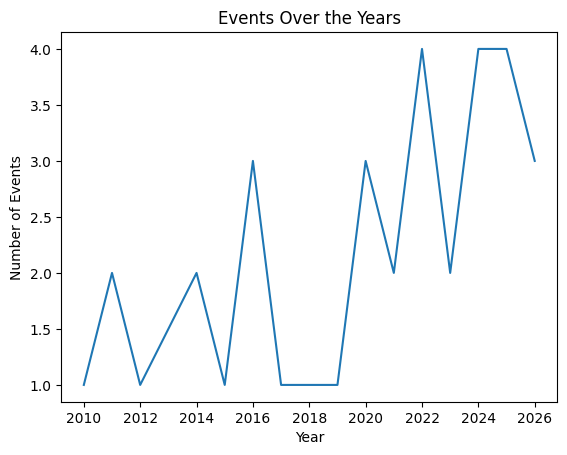

In [85]:
fig, ax = plt.subplots()
ax.plot(years)

plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.title('Events Over the Years')

plt.show();

From the line graph, we can see that the in the dataset, the least eventful year was 2018, with 1 event occurring. While the most eventful year is a tie between 2022 and 2024, with 4 events each.

Now we look at the `event_type` column. We want to know what was the most frequent type of event. Let's visualize this using a bar graph.

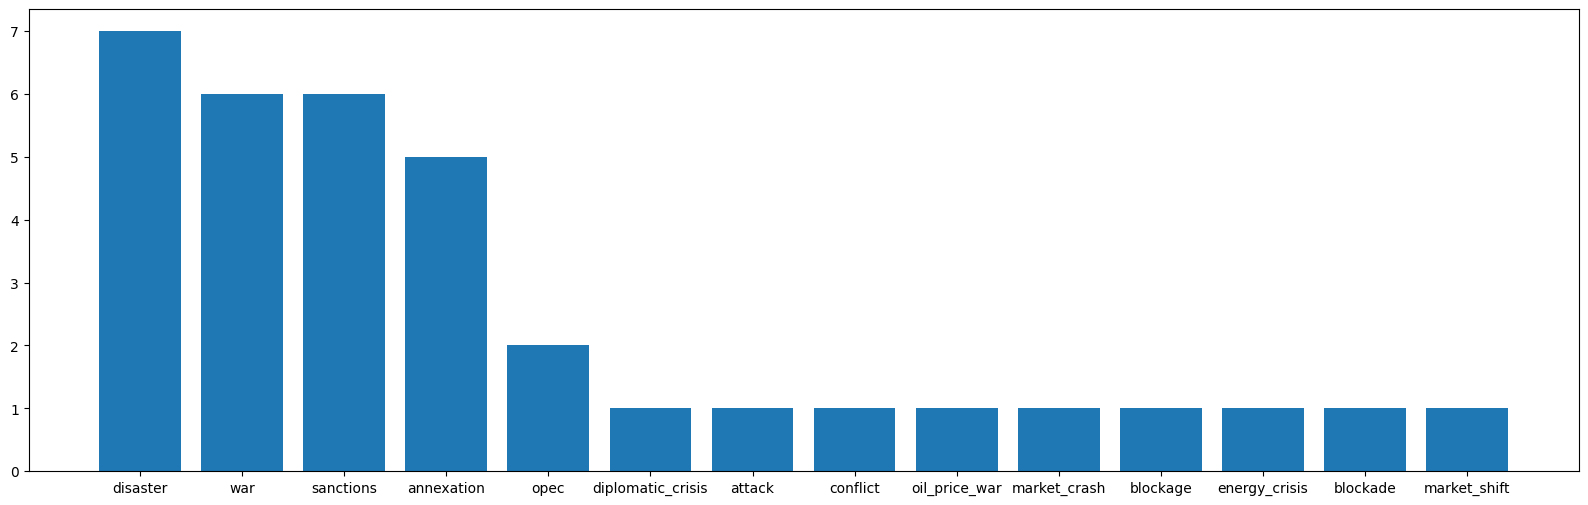

In [111]:
labels = events_timeline['event_type'].unique()
sizes = events_timeline['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(20, 6))
plt.bar(labels, sizes)
plt.show();

`disaster` is the most common type of event, occurring a total of 7 times, `war` and `sanctions` are in second with 6 times for both. `annexation` and `opec` come in third and fourth, with 5 and 2 occurrences respectively. Everything else is tied for last with 1 occurrence of each.

Although some events occur more frequently than others, this is **not** enough to say that one type of event is destructive than the others